In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc
cm = 1/2.54

In [2]:
ident = pd.read_csv('identifier.csv', sep = ';')
ident

,Identifier,Age_group
0,cc_DAL_0001,10
1,cc_DAL_0002,10
2,cc_DAL_0003,10
3,cc_DAL_0004,10
4,cc_DAL_0005,6
...,...,...
119,cc_DAL_0120,25
120,cc_DAL_0121,25
121,cc_DAL_0122,25
122,cc_DAL_0123,25


In [3]:
extracted_col = ident["Age_group"]

In [4]:
data = pd.read_csv('cell_counting_testing_set.csv', sep = ',')
data

,Unnamed: 0,nostitch,stitch025,stitch035,cellstitch
0,../../../agnawrot-nas/agmn-nas_home/mspringer/...,4071,707,831,485.0
1,../../../agnawrot-nas/agmn-nas_home/mspringer/...,4052,697,813,487.0
2,../../../agnawrot-nas/agmn-nas_home/mspringer/...,3283,610,674,399.0
3,../../../agnawrot-nas/agmn-nas_home/mspringer/...,3586,643,790,460.0
4,../../../agnawrot-nas/agmn-nas_home/mspringer/...,2579,405,485,291.0
...,...,...,...,...,...
119,../../../agnawrot-nas/agmn-nas_home/mspringer/...,4335,634,696,392.0
120,../../../agnawrot-nas/agmn-nas_home/mspringer/...,4784,665,724,489.0
121,../../../agnawrot-nas/agmn-nas_home/mspringer/...,4863,697,789,484.0
122,../../../agnawrot-nas/agmn-nas_home/mspringer/...,4529,666,740,475.0


In [5]:
data = data.join(extracted_col)

In [6]:
for i, row in data.iterrows():
    data.at[i,'Unnamed: 0'] = data.at[i,'Unnamed: 0'][-8:-4]

In [7]:
data

,Unnamed: 0,nostitch,stitch025,stitch035,cellstitch,Age_group
0,0001,4071,707,831,485.0,10
1,0002,4052,697,813,487.0,10
2,0003,3283,610,674,399.0,10
3,0004,3586,643,790,460.0,10
4,0005,2579,405,485,291.0,6
...,...,...,...,...,...,...
119,0120,4335,634,696,392.0,25
120,0121,4784,665,724,489.0,25
121,0122,4863,697,789,484.0,25
122,0123,4529,666,740,475.0,25


In [8]:
data.to_csv('cell_counting_testing_set_with_agegroup.csv', index=False)

In [8]:
frames_per_cell = data.nostitch / data.stitch025
data['frames_per_cell_025'] = frames_per_cell

frames_per_cell = data.nostitch / data.stitch035
data['frames_per_cell_035'] = frames_per_cell

In [9]:
cond = np.unique(data['Age_group'])

In [10]:
cond

array([ 6, 10, 15, 20, 25, 30])

In [11]:
all_025 = {}
for i in cond:
    all_025["{0}".format(i)] = np.array(data[data['Age_group'] == i]['stitch025'])

    
all_035 = {}
for i in cond:
    all_035["{0}".format(i)] = np.array(data[data['Age_group'] == i]['stitch035'])
    
all_fpc025 = {}
for i in cond:
    all_fpc025["{0}".format(i)] = np.array(data[data['Age_group'] == i]['frames_per_cell_025'])
    

all_fpc035 = {}
for i in cond:
    all_fpc035["{0}".format(i)] = np.array(data[data['Age_group'] == i]['frames_per_cell_035'])

In [12]:
F, p = sc.stats.f_oneway(all_025['6'],all_025['10'],all_025['15'],all_025['20'],all_025['25'],all_025['30'])
p

8.892182093178344e-10

In [14]:
data[data['Age_group'] == 15]

,Unnamed: 0,nostitch,stitch025,stitch035,cellstitch,Age_group,frames_per_cell_025,frames_per_cell_035
38,0039,4027,911,1092,696.0,15,4.420417,3.687729
39,0040,4035,1580,1799,721.0,15,2.553797,2.242913
40,0041,4939,755,899,561.0,15,6.541722,5.493882
41,0042,2588,900,999,437.0,15,2.875556,2.590591
42,0043,4608,841,1006,608.0,15,5.479191,4.580517
43,0044,4538,744,894,559.0,15,6.099462,5.076063
58,0059,51,13,13,8.0,15,3.923077,3.923077
59,0060,5,4,4,NaN,15,1.250000,1.250000
60,0061,4298,674,742,418.0,15,6.376855,5.792453
61,0062,4761,684,779,458.0,15,6.960526,6.111682


In [15]:
mean_025 = []
std_025 = []
for i in cond:
    mean_025 += [np.mean(np.array(data[data['Age_group'] == i]['stitch025']))]
    std_025 += [np.std(np.array(data[data['Age_group'] == i]['stitch025']))]
    
mean_035 = []
std_035 = []
for i in cond:
    mean_035 += [np.mean(np.array(data[data['Age_group'] == i]['stitch035']))]
    std_035 += [np.std(np.array(data[data['Age_group'] == i]['stitch035']))]
    
mean_no = []
std_no = []
for i in cond:
    mean_no += [np.mean(np.array(data[data['Age_group'] == i]['nostitch']))]
    std_no += [np.std(np.array(data[data['Age_group'] == i]['nostitch']))]
    
mean_cs = []
std_cs = []
for i in cond:
    mean_cs += [np.mean(np.array(data[data['Age_group'] == i]['cellstitch']))]
    std_cs += [np.std(np.array(data[data['Age_group'] == i]['cellstitch']))]

In [16]:
mean_fpc025 = []
std_fpc025 = []
len_025 = []
for i in cond:
    mean_fpc025 += [np.mean(np.array(data[data['Age_group'] == i]['frames_per_cell_025']))]
    std_fpc025 += [np.std(np.array(data[data['Age_group'] == i]['frames_per_cell_025']))]
    mean_fpc025 += [np.mean(np.array(data[data['Age_group'] == i]['frames_per_cell_025']))]
    len_025 += [len(np.array(data[data['Age_group'] == i]['frames_per_cell_025']))]
    
mean_fpc035 = []
std_fpc035 = []
len_035 = []
for i in cond:
    mean_fpc035 += [np.mean(np.array(data[data['Age_group'] == i]['frames_per_cell_035']))]
    std_fpc035 += [np.std(np.array(data[data['Age_group'] == i]['frames_per_cell_035']))]
    len_035 += [len(np.array(data[data['Age_group'] == i]['frames_per_cell_035']))]

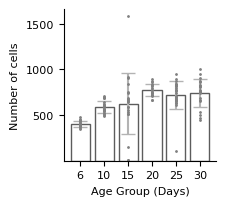

In [19]:
plt.figure(figsize=(5*cm,5*cm))
ax = plt.subplot(111)
plt.bar(range(6), mean_025,alpha=0.8,edgecolor=[0.2,0.2,0.2],facecolor='w')
plt.errorbar(range(6), mean_025,yerr=std_025,linestyle='',capsize=5,color=[0.7,0.7,0.7])
plt.xticks(range(6),cond,fontsize=8)
plt.yticks([500,1000,1500],fontsize=8)
#plt.ylim(400,450)
ax.spines[['right', 'top']].set_visible(False)
plt.xlabel('Age Group (Days)',fontsize=8)
plt.ylabel('Number of cells',fontsize=8)
for idx,i in enumerate(cond):
    single_points = all_025[str(i)]
    plt.plot(np.ones(len(single_points))*idx,single_points,'.',color=[0.5,0.5,0.5],markersize=2)
plt.savefig('comparison025.pdf',bbox_inches = 'tight')

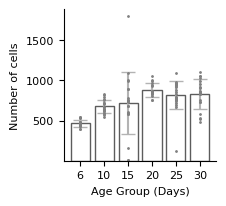

In [48]:
plt.figure(figsize=(5*cm,5*cm))
ax = plt.subplot(111)
plt.bar(range(6), mean_035,alpha=0.8,edgecolor=[0.2,0.2,0.2],facecolor='w')
plt.errorbar(range(6), mean_035,yerr=std_035,linestyle='',capsize=5,color=[0.7,0.7,0.7])
plt.xticks(range(6),cond,fontsize=8)
plt.yticks([500,1000,1500],fontsize=8)
#plt.ylim(400,450)
ax.spines[['right', 'top']].set_visible(False)
plt.xlabel('Age Group (Days)',fontsize=8)
plt.ylabel('Number of cells',fontsize=8)
for idx,i in enumerate(cond):
    single_points = all_035[str(i)]
    plt.plot(np.ones(len(single_points))*idx,single_points,'.',color=[0.5,0.5,0.5],markersize=2)
plt.savefig('comparison035.pdf',bbox_inches = 'tight')

In [21]:
np.mean(mean_fpc035)

5.127128833353324

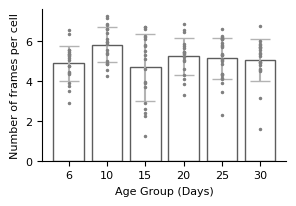

In [34]:
plt.figure(figsize=(8*cm,5*cm))
ax = plt.subplot(111)
plt.bar(range(6), mean_fpc035,alpha=0.8,edgecolor=[0.2,0.2,0.2],facecolor='w')
plt.errorbar(range(6), mean_fpc035,yerr=std_fpc035,linestyle='',capsize=7,color=[0.7,0.7,0.7])
plt.xticks(range(6),cond,fontsize=8)
plt.yticks(fontsize=8)
#plt.ylim(0,10)
ax.spines[['right', 'top']].set_visible(False)
plt.xlabel('Age Group (Days)',fontsize=8)
plt.ylabel('Number of frames per cell',fontsize=8)
for idx,i in enumerate(cond):
    single_points = all_fpc035[str(i)]
    plt.plot(np.ones(len(single_points))*idx,single_points,'.',color=[0.5,0.5,0.5],markersize=3)

plt.savefig('comparison_fpc_035.pdf',bbox_inches = 'tight')

In [73]:
T, p = sc.stats.ttest_ind(all_fpc035['10'],all_fpc035['30'])
'{0:.20f}'.format(p)

'0.02168349178502269881'